<a href="https://colab.research.google.com/github/krishnasaijoga/ScalerCaseStudies/blob/main/UncoveringHiddenCountrySegmentsCS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uncovering Hidden Country Segments for Global Development Strategy

## Problem Statement

Global development organizations need to allocate development resources effectively across countries with different socio-economic realities. A single global policy approach may not work because countries differ in health outcomes, income levels, trade dependency, inflation, fertility, and GDP per capita.

The objective of this case study is to apply unsupervised learning techniques to identify hidden country segments using socio-economic indicators. These segments can help policymakers design targeted development strategies for different groups of countries.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from scipy.cluster.hierarchy import linkage, dendrogram

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

In [2]:
def load_data(path: str) -> pd.DataFrame:
  !gdown --fuzzy --output ad_dataset.csv "$DATA_PATH" # $DATA_PATH means to parse url before retrieval
  data=pd.read_csv("/content/ad_dataset.csv")
  return data

In [3]:
#cleaning column names
def column_name_cleaning(df):
  df.columns=df.columns.str.strip()
  df.columns=df.columns.str.lower()
  df.columns=df.columns.str.replace(' ','_')
  return df

In [4]:
DATA_PATH='https://drive.google.com/file/d/1SWUXaC78y2lnahVnUwBPmyXOicJW41Po/view?usp=sharing'
df=load_data(DATA_PATH)

Downloading...
From: https://drive.google.com/uc?id=1SWUXaC78y2lnahVnUwBPmyXOicJW41Po
To: /content/ad_dataset.csv
100% 9.23k/9.23k [00:00<00:00, 15.3MB/s]


In [5]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [6]:
df.shape

(167, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [9]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [10]:
df.duplicated().sum()

np.int64(0)

## Initial Data Inspection
The dataset contains 167 rows and 10 columns. Out of these, country column is a categorical identifier and rest are numerical indicators of socio-economy of a country covering health, trade, income, fertility, life expectancy, GDP per capita, and inflation.

There are no missing values in the dataset. There are no duplicate rows as well. So, there is no requirement of handling missing values or duplicate values before analysis.

The summary statistics show that variables are measured on different scales. life_expec ranges from 32.7 to 82.8, while gdp ranges from 231 to 105000, and income ranges from 609 to 125000. This necessitates feature scaling before applying any distance-based clustering algorithm like K-Means, Hierarchical clustering, and DBSCAN.

Some variables show strong sign of extreme values like child_mort which has maximum value of 208 compared to median value of 19.3, inflation has a maximum value of 104 compared to median value of 5.39, and exports go upto 200 compared to median of 35. These extreme values neede to be carefully analysed because they can be countries in critical and structurally organised unique economies and not simply data errors.

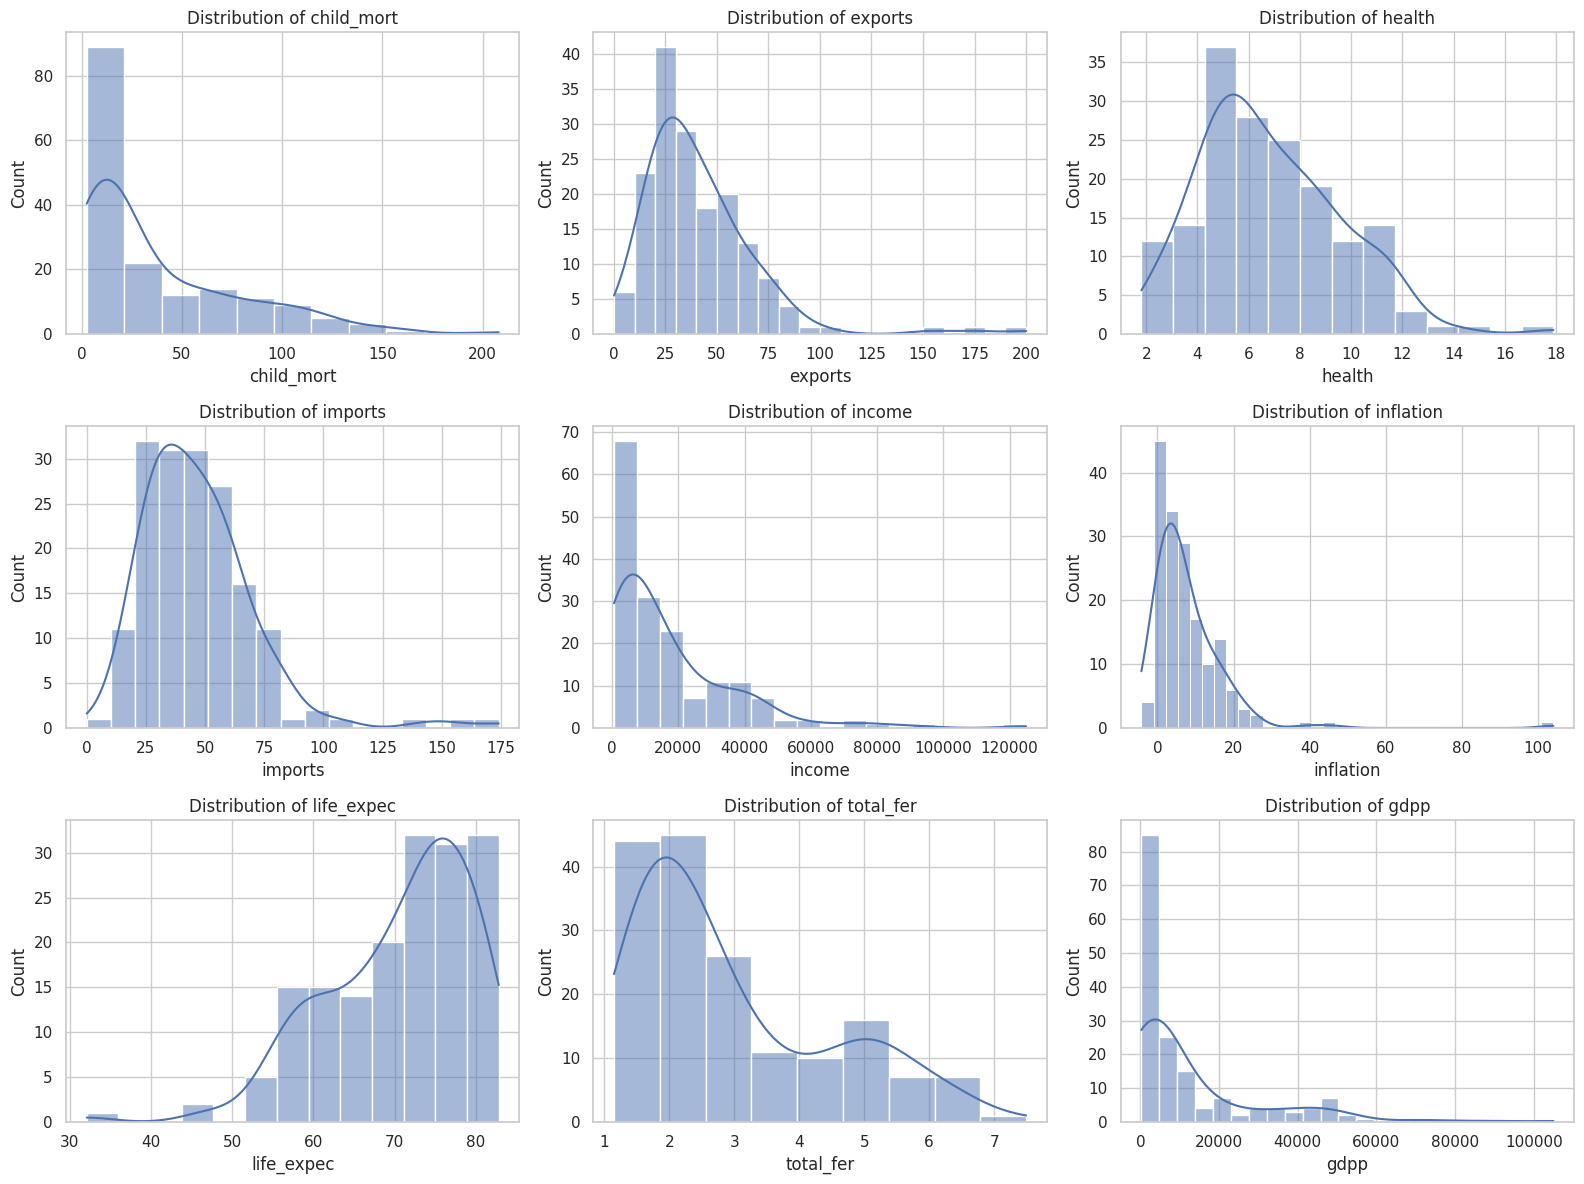

In [11]:
num_cols=df.drop(columns=['country']).columns
plt.figure(figsize=(16,12))
for i, col in enumerate(num_cols,1):
  plt.subplot(3,3,i)
  sns.histplot(df[col],kde=True)
  plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

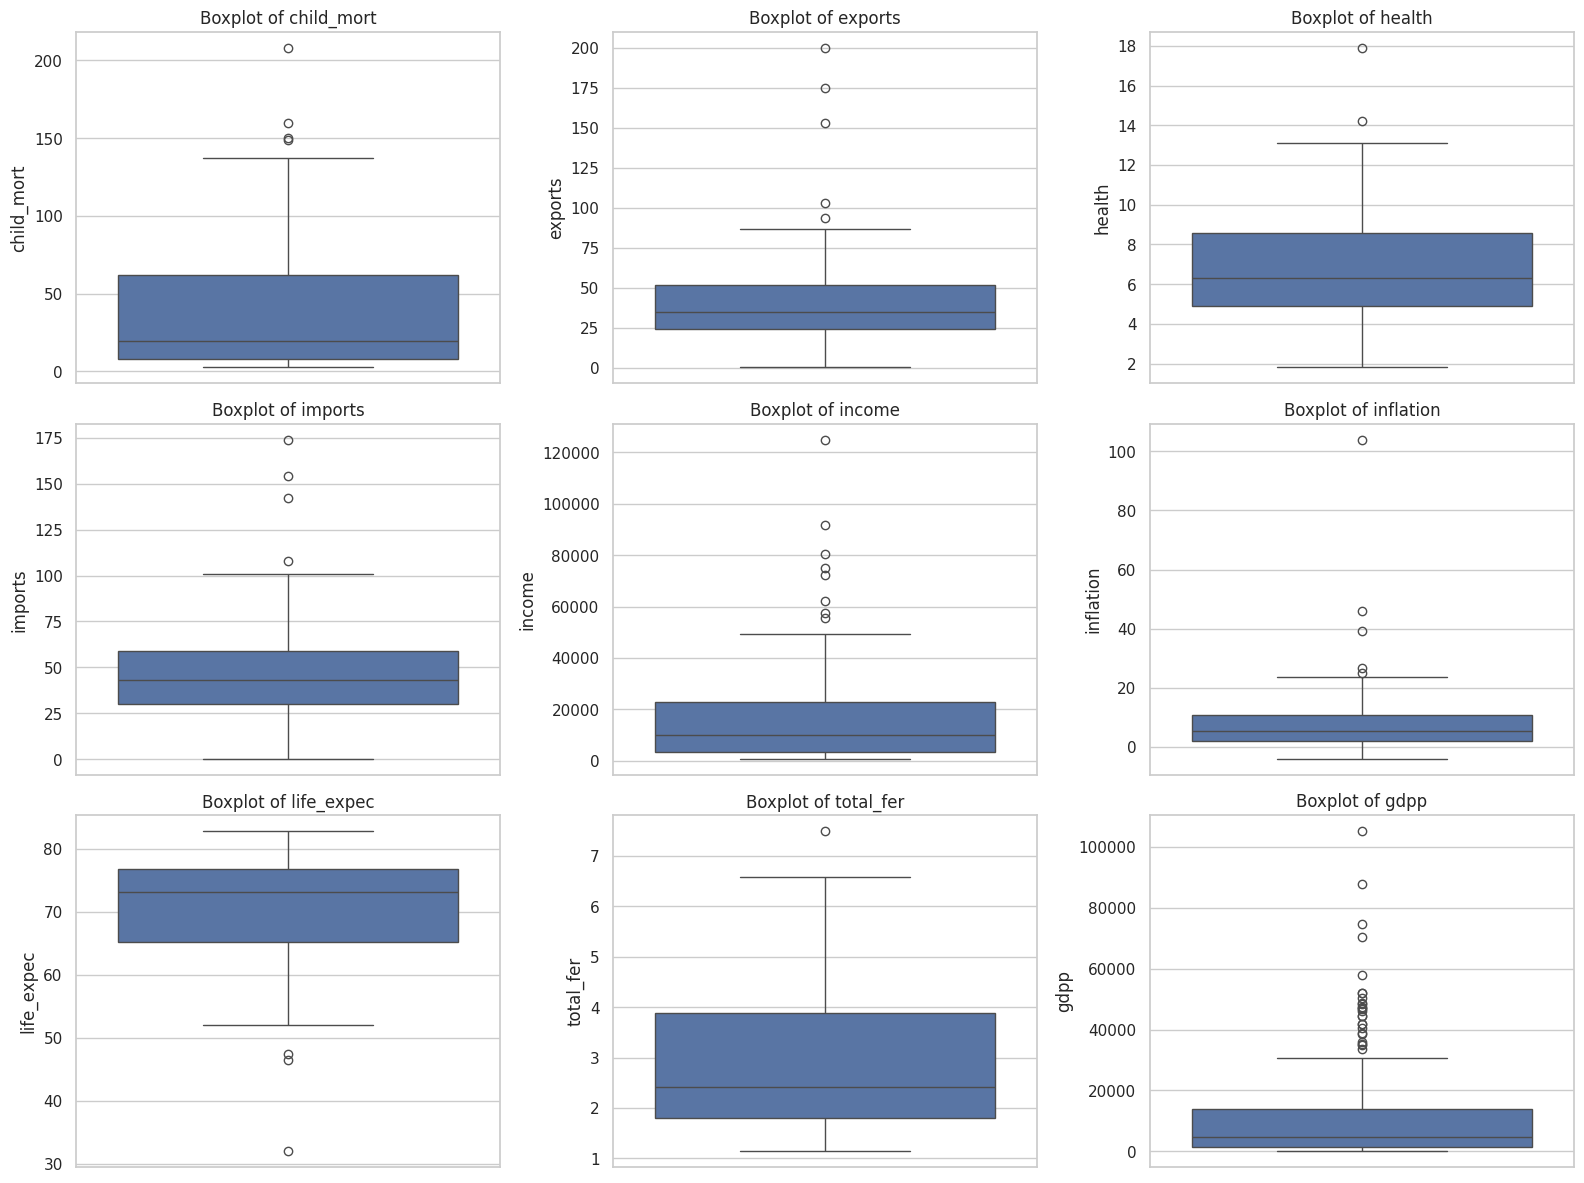

In [12]:
plt.figure(figsize=(16,12))
for i,col in enumerate(num_cols,1):
  plt.subplot(3,3,i)
  sns.boxplot(y=df[col])
  plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [13]:
skewness=df[num_cols].skew().sort_values(ascending=False)
skewness

,0
inflation,5.154049
exports,2.445824
income,2.231480
gdpp,2.218051
imports,1.905276
child_mort,1.450774
total_fer,0.967092
health,0.705746
life_expec,-0.970996


In [14]:
skewness_df=pd.DataFrame({'Feature':skewness.index,'Skewness':skewness.values})
skewness_df

,Feature,Skewness
0,inflation,5.154049
1,exports,2.445824
2,income,2.231480
3,gdpp,2.218051
4,imports,1.905276
5,child_mort,1.450774
6,total_fer,0.967092
7,health,0.705746
8,life_expec,-0.970996


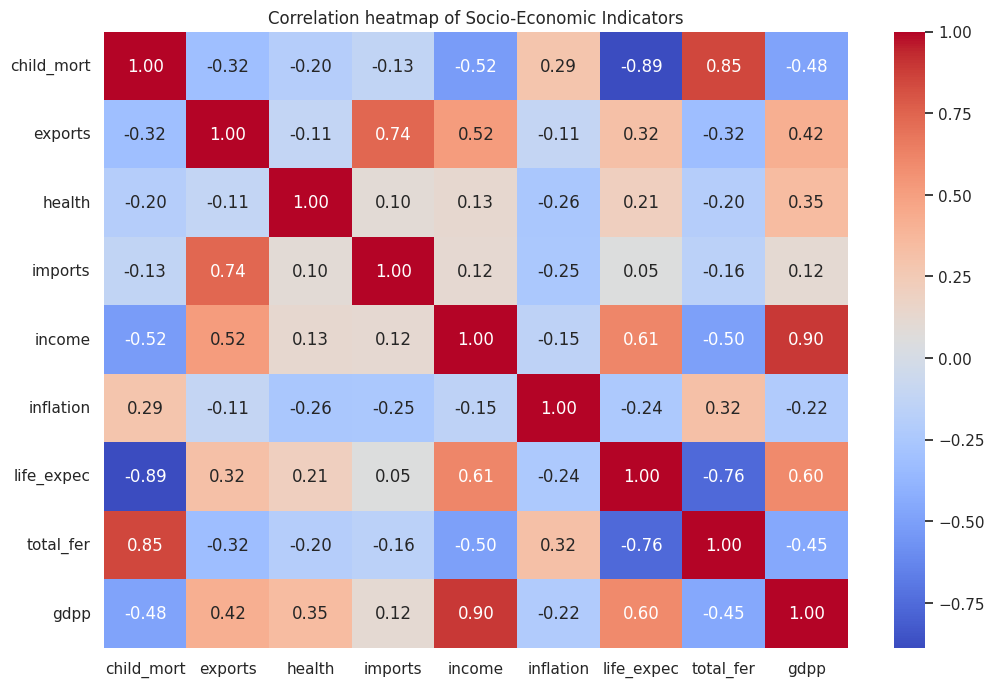

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation heatmap of Socio-Economic Indicators")
plt.show()

In [16]:
def top_bottom_n_countries_by_feature(feature, n=5):
  print(f"Top {n} Countries by {feature}\n","*"*50)
  print(df[['country',feature]].sort_values(by=feature,ascending=False).head(n),"\n","-"*50)
  print(f"Bottom {n} Countries by {feature}\n","*"*50)
  print(df[['country',feature]].sort_values(by=feature,ascending=True).head(n),"\n","-"*50)

In [17]:
for feature in num_cols:
  top_bottom_n_countries_by_feature(feature,3)

Top 3 Countries by child_mort
 **************************************************
          country  child_mort
66          Haiti       208.0
132  Sierra Leone       160.0
32           Chad       150.0 
 --------------------------------------------------
Bottom 3 Countries by child_mort
 **************************************************
        country  child_mort
68      Iceland         2.6
91   Luxembourg         2.8
133   Singapore         2.8 
 --------------------------------------------------
Top 3 Countries by exports
 **************************************************
        country  exports
133   Singapore    200.0
91   Luxembourg    175.0
98        Malta    153.0 
 --------------------------------------------------
Bottom 3 Countries by exports
 **************************************************
         country  exports
107      Myanmar    0.109
149  Timor-Leste    2.200
50       Eritrea    4.790 
 --------------------------------------------------
Top 3 Countries by healt

## Exploratory Data Analysis: Distributions, Outliers, and Relationships
The distribution plots and box plots show that most of the features are right-skewed especially inflation, exports, income, gdpp, income, child_mort. This implies that most of them have moderate or low values except for a few countries have extremely high values.

The skewness values confirm this pattern:
- 'inflation has the highest positive skewness of 5.15, mainly due to countries like Nigeria, Venezuela, Mongolia having very high inflation.
- exports, income, gdpp, imports are also strongly right-skewed, showing that few countries have high trade activity or very high GDP per capita/income.
- life_expectancy is left skewed indicating that most countries have high expectancy compared to few of them like Haiti, Lesotho, Central African Republic with low expectancy.

The boxplots also show visible outliers in several features. However, they might not be data errors. Countries with low expectancy, and high child_mortality represent most vulnerable countries whereas countries with high gdpp, income, exports represent structurally strong economies and not incorrect data points.

Since, the goal is to identify meaningful segments we should not blindly remove these outliers. Any capping decision must balance statistical stability with business interpretability.

## Correlation Analysis
The correaltion heatmap shows several strong relationships between the socio-economic indicators:
1. 'child_mort' and 'life_expec' have a strong negative correlation of -0.89. This means the countries with high child mortality generally have lower life expectancy.
2. 'child_mort' and 'total_fer' have strong correaltiuon of 0.85. This means that countries with high child mortality have high total fertility rate.
3. 'income' and 'gdpp' have strong correaltion of 0.9. This means that countries with high gdpp have income.
4. 'exports' and 'imports' have strong correlation of 0.74. This means that countries with more exports also have more imports.
5. 'life_expec' has positive correlation with 'income' and 'gdpp', while it has negative correaltion with 'child_mort' and 'total_fer'. This supports that health and economic indicators move together.

Overall, the correaltion analysis shows that the dataset contains groups of related indicators. PCA can help reduce this overlap by reducing variables into fewer independent components before clustering.

## Top and Bottom Country Observations
The top and bottom country analysis provides useful information before clustering.
COuntries such as Haiti, Sierra Leone, and Chad have the highest child mortality while Iceland, Luxemborg, and Singapore have the lowest child mortality. This shows clear difference in health and development countries.
For economic indicators, Qatar, Luxemborg, and Brunei have highest income levels, while Congo Democratic Republic, Liberia, and Burundi have the lowest income levels.
For life expectancy, Japan, Singapore, and Switzerland are at the top, while Haiti, Lesotho, Central African Republic are at the bottom.
For trade inidicators, Singapore, Luxemborg, and Malta have very high imports and exports. These indicate they are highly trade dependent countries.
These observations suggest that the dataset contains countries with different socio-economic profiles. This supports the need for clustering because countries cannot be treated as one uniform group for global development strategy.

## Business Insights from EDA
The EDA shows that countries differ sharply across health, trade, income, inflation, and demographic indicators.
This supports the objective of using unsupervised learning to identify hidden segments instead of single policy recommendation for all countries, clustering can help create targeted strategies for different development groups.

In [18]:
outlier_summary=[]
for col in num_cols:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-IQR*1.5
  upper_bound=Q3+IQR*1.5

  outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
  outlier_summary.append({
      'Feature':col,
      'Lower Bound':lower_bound,
      'Upper Bound':upper_bound,
      'Outlier count':outliers.shape[0]
  })
outlier_summary_df=pd.DataFrame(outlier_summary)
outlier_summary_df

,Feature,Lower Bound,Upper Bound,Outlier count
0,child_mort,-72.5250,142.8750,4
1,exports,-17.5250,92.6750,5
2,health,-0.6000,14.1200,2
3,imports,-12.6250,101.5750,4
4,income,-25812.5000,51967.5000,8
5,inflation,-11.6000,24.1600,5
6,life_expec,48.0500,94.0500,3
7,total_fer,-1.3325,7.0075,1
8,gdpp,-17750.0000,33130.0000,25


In [19]:
df_capped=df.copy()
for col in num_cols:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-IQR*1.5
  upper_bound=Q3+IQR*1.5

  df_capped[col]=np.where(df_capped[col]<lower_bound,lower_bound,df_capped[col])
  df_capped[col]=np.where(df_capped[col]>upper_bound,upper_bound,df_capped[col])
df_capped.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,37.698204,38.443293,2.6000,8.250,19.30,62.10,142.8750
exports,167.0,39.543557,21.301318,0.1090,23.800,35.00,51.35,92.6750
health,167.0,6.792575,2.668103,1.8100,4.920,6.32,8.60,14.1200
imports,167.0,45.862071,20.338815,0.0659,30.200,43.30,58.75,101.5750
income,167.0,15921.574850,15207.197459,609.0000,3355.000,9960.00,22800.00,51967.5000
inflation,167.0,7.065066,6.704968,-4.2100,1.810,5.39,10.75,24.1600
life_expec,167.0,70.663772,8.522535,48.0500,65.300,73.10,76.80,82.8000
total_fer,167.0,2.945075,1.505564,1.1500,1.795,2.41,3.88,7.0075
gdpp,167.0,10351.281437,11612.044330,231.0000,1330.000,4660.00,14050.00,33130.0000


## Outlier Detection and Treatment
Outliers were detected using IQR method, where outliers are either below Q1-1.5xIQR or above Q3+1.5xIQR
The number of detected outliers differs substantially across features:
- 'gdpp' contains largest numer of outliers (~15%). This indicates that GDP is highly unequal across countries. THese values might not necessarily be data errors; but they represent genuienly wealthy economies that differ substantially from others.
- 'income' contains 8 outliers
- 'exports' and 'inflation' have 5 outliers each.
- 'child_mort' and 'imports' contains 4 outliers each
- 'life_expec' contains 3 outliers
- 'health' contians 2 outliers
- 'total_fer' contains only 1 outlier
Extreme values in 'child_mort', 'life_expec', and 'inflation' may represent countries facing severe development or economic challenges. Removing them would be inappropriate because they are highly rlevant to the case study in identifying countries that require targeted development intervention.

TO reduce excessive influence of extreme numerical values on distance clustering they are capped. However, original dataset is also preserved so that clustering results can be compared and capping effects can be evaluated.

In [20]:
df_original=df.copy()#original dataset
df_model=df_capped.copy()#capped dataset

## Q2. Why might capping extreme high/low values (like max child_mort) be counterproductive when the goal is to identify countries in the most critical need of aid?

Capping values can be counter productive when the target is to identify countries that need developmental intervention the most, because the extreme observations might carry the most important devlopmental information.
For example, Haiti which has the highest 'child_mortality' of 208 has been capped to 142. Though this limits the statistical influence, it also reduces the visibility of severity of the country's condition making it seem similar to other countries with high mortaility than it actually is.
Likewise, capping inflation and low life expectancy can hide the intensity of the humanitarian crisis happening. As a result the algorithm might fail to isolate the countries that require most urgent and specialized intervention.
Therefore, extreme observations should not be removed automatically. A better approach is to retain the original version and compare the results to asses whether these countries form meaningful and policy-relevant segments

In [21]:
countries=df['country'].copy()
X_capped=df_capped.drop(columns=['country'],errors='ignore')
X_original=df_original.drop(columns=['country'],errors='ignore')

In [22]:
from sklearn.preprocessing import StandardScaler
scaler_capped=StandardScaler()
X_capped_scaled=scaler_capped.fit_transform(X_capped)
scaler_original=StandardScaler()
X_capped_original=scaler_original.fit_transform(X_original)

In [23]:
X_capped_scaled_df=pd.DataFrame(X_capped_scaled,columns=X_capped.columns,index=df.index)
X_capped_scaled_df

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.369802,-1.391107,0.296013,-0.047444,-0.943936,0.355270,-1.702225,1.915276,-0.846341
1,-0.550464,-0.543547,-0.091190,0.135021,-0.395181,-0.385208,0.663321,-0.862779,-0.540827
2,-0.271295,-0.053846,-0.985893,-0.713196,-0.199291,1.351551,0.686859,-0.036691,-0.508868
3,2.121210,1.071524,-1.482114,-0.146074,-0.660984,2.293979,-1.243238,2.141784,-0.589198
4,-0.714835,0.280469,-0.286671,0.642965,0.209637,-0.841463,0.722166,-0.543003,0.159686
...,...,...,...,...,...,...,...,...,...
162,-0.221723,0.332264,-0.579893,0.337212,-0.855555,-0.664945,-0.901941,0.369691,-0.637569
163,-0.537419,-0.520004,-0.707708,-1.393742,0.038151,2.557260,0.557401,-0.316495,0.271975
164,-0.375657,1.528265,0.017828,1.693373,-0.753982,0.753184,0.286717,-0.662919,-0.780954
165,0.485332,-0.449374,-0.606208,-0.565251,-0.754642,2.473489,-0.372341,1.149146,-0.780954


In [24]:
scaling_validation_df=pd.DataFrame({
    'Mean':X_capped_scaled_df.mean(),
    'Standard Deviation':X_capped_scaled_df.std(ddof=0)
})
scaling_validation_df.round(3)

,Mean,Standard Deviation
child_mort,-0.0,1.0
exports,0.0,1.0
health,0.0,1.0
imports,0.0,1.0
income,0.0,1.0
inflation,-0.0,1.0
life_expec,0.0,1.0
total_fer,0.0,1.0
gdpp,0.0,1.0


## Feature Scaling
Standard scaler was applied to make each and every feature to approximately mean =0 and std dev =1. This ensures every indicator contributes on a comparable scale before PCA and clustering.

## Q1. If Standard Scaling was skipped, which features (e.g., gdpp vs. life_expec) would unfairly dominate the clustering distance calculation?

Ans. Had Scaling not been done, the features like gdpp, income would dominate the clustering distance calculations because their values range in 100. Conversely, features like life_expec, total_fer, health have smaller values even though they are important indicators of devlopment they tend to have lesser influence on clustering.
As a result, the clustering would seprate countries with higher economic magnitudes rather than creating a balanced socio-economic segmentation. Standard scaling helps in bringing all features into comparable units.

In [25]:
from sklearn.decomposition import PCA
pca_full=PCA()
x_pca_full=pca_full.fit_transform(X_capped_scaled)

In [26]:
explained_variance_df=pd.DataFrame({
    'Principal Component':[f"PC{i+1}" for i in range(len(pca_full.explained_variance_ratio_))],
    'Explained Variance Ratio':pca_full.explained_variance_ratio_,
    'Cumilative Variance':np.cumsum(pca_full.explained_variance_ratio_)
})
explained_variance_df

,Principal Component,Explained Variance Ratio,Cumilative Variance
0,PC1,0.488924,0.488924
1,PC2,0.164528,0.653452
2,PC3,0.137568,0.791020
3,PC4,0.095046,0.886066
4,PC5,0.065003,0.951069
5,PC6,0.020118,0.971187
6,PC7,0.016559,0.987746
7,PC8,0.008995,0.996741
8,PC9,0.003259,1.000000


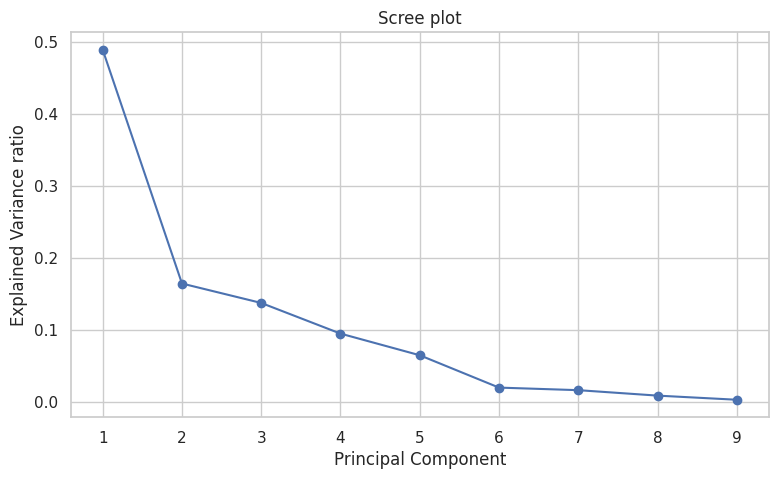

In [27]:
plt.figure(figsize=(9,5))
plt.plot(range(1,len(pca_full.explained_variance_ratio_)+1),pca_full.explained_variance_ratio_,marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance ratio")
plt.title("Scree plot")
plt.grid(True)
plt.show()

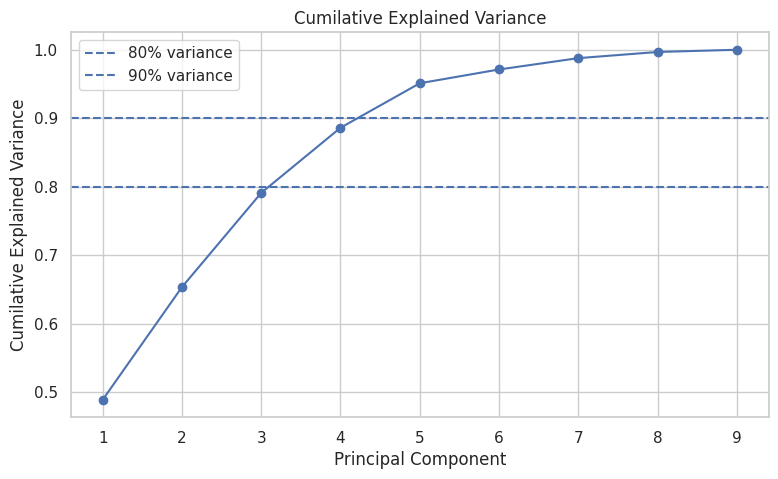

In [28]:
plt.figure(figsize=(9,5))
plt.plot(range(1,len(pca_full.explained_variance_ratio_)+1),np.cumsum(pca_full.explained_variance_ratio_),marker='o')
plt.axhline(y=0.80,linestyle='--',label='80% variance')
plt.axhline(y=0.90,linestyle='--',label='90% variance')
plt.xlabel("Principal Component")
plt.ylabel("Cumilative Explained Variance")
plt.title("Cumilative Explained Variance")
plt.xticks(range(1,len(pca_full.explained_variance_ratio_)+1))
plt.legend()
plt.grid(True)
plt.show()

In [29]:
cumilative_variance=np.cumsum(pca_full.explained_variance_ratio_)

components_for_80=np.argmax(cumilative_variance>=0.80)+1
components_for_90=np.argmax(cumilative_variance>=0.9)+1
print("Components required for atleast 80% variance:",components_for_80)
print("Components required for atleast 80% variance:",components_for_90)

Components required for atleast 80% variance: 4
Components required for atleast 80% variance: 5


In [30]:
n_components_selected=components_for_80
pca=PCA(n_components=n_components_selected)
X_pca=pca.fit_transform(X_capped_scaled)
pca_columns=[f"PC{i+1}" for i in range(n_components_selected)]
x_pca_df=pd.DataFrame(X_pca,columns=pca_columns,index=df.index)
x_pca_df['country']=df['country']
x_pca_df.head()

,PC1,PC2,PC3,PC4,country
0,-3.177917,-0.251292,1.011474,0.778804,Afghanistan
1,0.434979,-0.218700,0.292591,-1.391241,Albania
2,-0.416784,-0.613870,-1.637859,-0.615021,Algeria
3,-3.306409,1.066649,-2.151219,1.698677,Angola
4,1.253246,0.547778,0.136955,-0.716890,Antigua and Barbuda


In [31]:
loadings_df=pd.DataFrame(
    pca.components_.T,
    index=X_capped.columns,
    columns=pca_columns
)
loadings_df

,PC1,PC2,PC3,PC4
child_mort,-0.419443,0.073348,0.084502,0.387524
exports,0.242616,0.588411,-0.315113,0.210441
health,0.165009,-0.146887,0.682955,0.312886
imports,0.104202,0.740034,0.223213,-0.017005
income,0.409415,-0.098691,-0.177098,0.447997
inflation,-0.222526,-0.124250,-0.575167,0.212704
life_expec,0.426822,-0.161888,-0.108076,-0.208106
total_fer,-0.404530,0.044268,0.045972,0.439500
gdpp,0.405166,-0.160689,-0.036565,0.474278


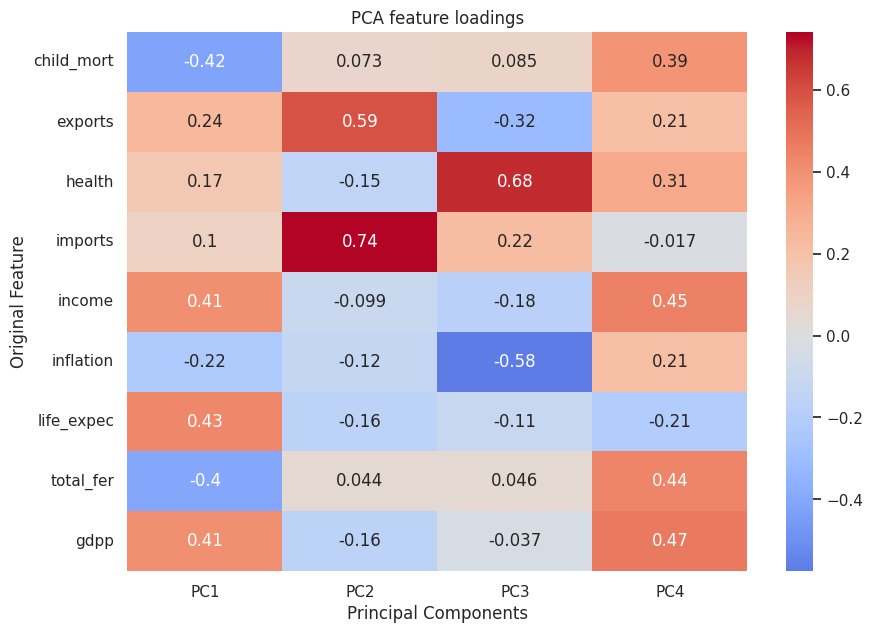

In [32]:
plt.figure(figsize=(10,7))
sns.heatmap(loadings_df,annot=True,cmap='coolwarm',center=0)
plt.title("PCA feature loadings")
plt.xlabel("Principal Components")
plt.ylabel("Original Feature")
plt.show()

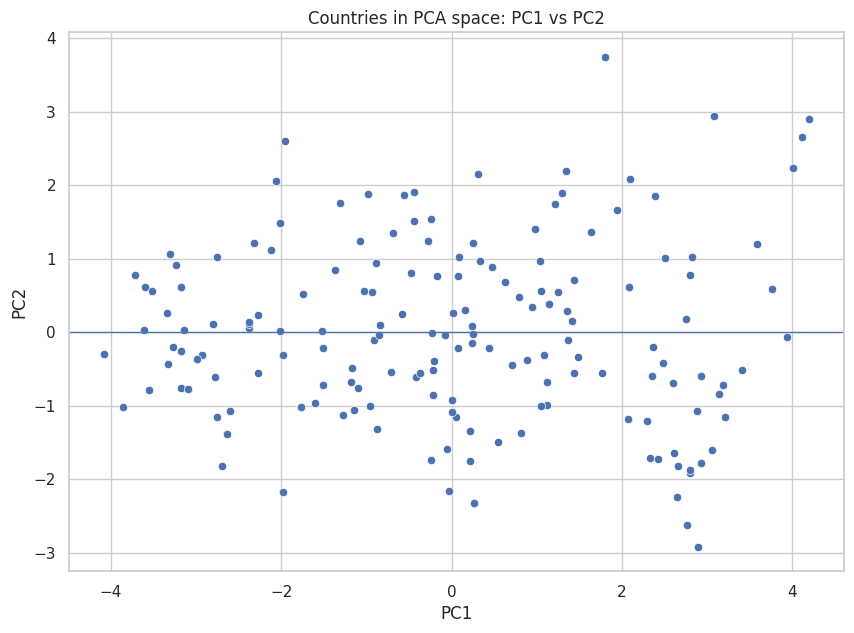

In [33]:
plt.figure(figsize=(10,7))
sns.scatterplot(x=x_pca_df['PC1'],y=x_pca_df['PC2'])
plt.axhline(0,linewidth=0.8)
plt.axhline(0,linewidth=0.9)
plt.title("Countries in PCA space: PC1 vs PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## PCA Component Selection

Principal Component Analysis was applied to the standardized, IQR-capped numerical data.

PC1 explains 48.89% of the total variance, while PC2 explains an additional 16.45%. Together, the first two components explain 65.35% of the variance.

The cumulative variance reaches:

- 79.10% with 3 components
- 88.61% with 4 components
- 95.11% with 5 components

Since three components fall slightly below the 80% target, four principal components were selected for clustering. These four components retain 88.61% of the original dataset variance, providing a strong balance between dimensionality reduction and information preservation.

PC1 and PC2 will be used for two-dimensional visualization, while PC1 through PC4 will be used as the actual input to the clustering algorithms.

## Interpretation of Principal Components

PC1 is primarily influenced positively by `life_expec`, `income`, and `gdpp`, and negatively by `child_mort` and `total_fer`. It therefore represents an overall socio-economic development dimension. Countries with high PC1 scores are generally wealthier, have higher life expectancy, lower child mortality, and lower fertility.

PC2 is dominated by `imports` and `exports`. It represents trade intensity or openness, separating highly trade-dependent economies from countries with lower international trade activity.

PC3 has a strong positive loading for `health` and a strong negative loading for `inflation`. It can be interpreted as a health-investment versus macroeconomic-stress dimension.

PC4 contains contributions from `gdpp`, `income`, `total_fer`, and `child_mort`. It captures more complex differences between countries that are not fully explained by the broad development and trade dimensions.

Overall, PCA successfully summarizes the original socio-economic indicators into four meaningful dimensions while retaining 88.61% of the total variance.

In [34]:
pca_country_df=x_pca_df.copy()
for pc in ['PC1','PC2','PC3','PC4']:
  print("Top 5 countries by PC")
  display(pca_country_df[['country',pc]].sort_values(pc,ascending=False).head())
  print("Bottom 5 countries by PC")
  display(pca_country_df[['country',pc]].sort_values(pc,ascending=True).head())
  print("*"*50)

Top 5 countries by PC


,country,PC1
133,Singapore,4.195098
91,Luxembourg,4.109719
73,Ireland,4.005064
145,Switzerland,3.931642
110,Netherlands,3.760342


Bottom 5 countries by PC


,country,PC1
31,Central African Republic,-4.072576
113,Nigeria,-3.857305
32,Chad,-3.714829
97,Mali,-3.605238
37,"Congo, Dem. Rep.",-3.601937


**************************************************
Top 5 countries by PC


...

**************************************************
Top 5 countries by PC


,country,PC4
49,Equatorial Guinea,3.164564
132,Sierra Leone,2.113699
37,"Congo, Dem. Rep.",1.884587
3,Angola,1.698677
113,Nigeria,1.606958


Bottom 5 countries by PC


,country,PC4
6,Armenia,-1.639069
34,China,-1.460004
107,Myanmar,-1.456567
12,Bangladesh,-1.442332
30,Cape Verde,-1.433172


**************************************************


In [35]:
X_cluster=x_pca_df[['PC1','PC2','PC3','PC4']].copy()

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values=range(2,11)

inertia_scores=[]
silhouette_scores=[]

for k in k_values:
  kmeans=KMeans(n_clusters=k,random_state=42,n_init=20)
  labels=kmeans.fit_predict(X_cluster)
  inertia_scores.append(kmeans.inertia_)
  silhouette_scores.append(silhouette_score(X_cluster,labels))
k_selection_df=pd.DataFrame({
    'k':list(k_values),
    'Inertia':inertia_scores,
    'Silhouette Score':silhouette_scores
})
k_selection_df

,k,Inertia,Silhouette Score
0,2,822.509626,0.323659
1,3,604.938977,0.320761
2,4,506.977407,0.328135
3,5,429.498481,0.304817
4,6,374.568206,0.324911
5,7,328.653067,0.312519
6,8,295.649323,0.320441
7,9,268.741046,0.298725
8,10,242.689241,0.299149


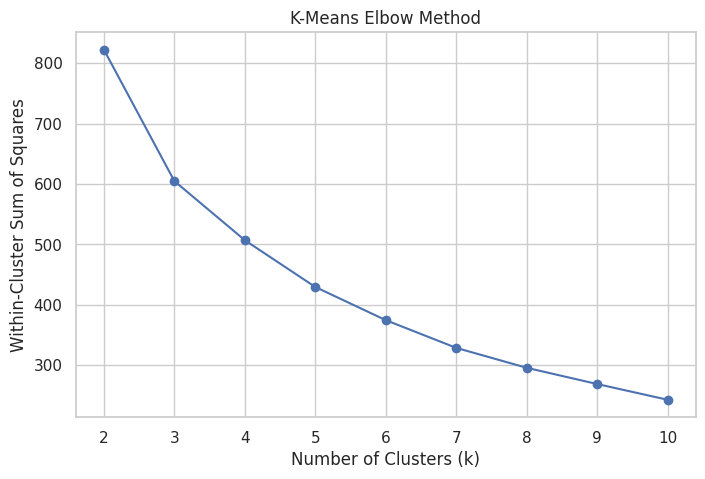

In [37]:
plt.figure(figsize=(8,5))
plt.plot(k_selection_df['k'],k_selection_df['Inertia'],marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares")
plt.title("K-Means Elbow Method")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

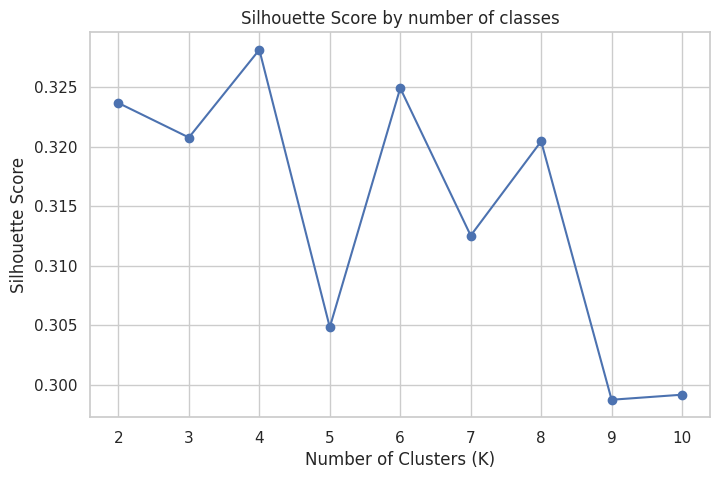

In [38]:
plt.figure(figsize=(8,5))

plt.plot(k_selection_df['k'],k_selection_df['Silhouette Score'],marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by number of classes")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

## Selecting Optimal Number of K-Means Clusters
THe optimal number of K-Means clusters are evaluated using both elbow method and silhouette score methods.
Elbow method indicates that the inertia reduction beyond K=4 is gradual, hence a substantial reduction in within-cluster sum of squares up to approxiamately k=4. On further addition of cluster there is only diminishing improvement in inertia.
The highest silhouette score is also obtained at K=4 (0.328), indicating better cluster cohesion and separation at this K.
Although silhouette score is positive, it is not moderate rather than high, suggesting that meaningful country segments exist, but some overlap remains may be due to socio-economic development occurring in a continum.
Based on statistical evidence and policy practicality, 4 segments are selected for the final K-Means model.

### Q3. If K-Means yields a very high Silhouette Score, what does this imply about the separation and cohesion of the identified country segments?

Ans. A very high silhouette score means that countries in a segment are very similar on socio-economic metrics and are different from any other countries from a different cluster.
From a policy perspective, this would suggest that the identical country segments have strong internal cohesion and clear separation. As a result, cluster targeted development programs can be designed with greater confidence because each segment has distinct socio-economic profile.
But for this case study, optimal K is 4 with silhouetter score =0.328 implying that clusters are meaningful but moderately overlapping rather than perfectly separated groups.

In [39]:
final_k=4
kmeans=KMeans(n_clusters=final_k,random_state=42,n_init=20)

kmeans_labels=kmeans.fit_predict(X_cluster)
df_results=df.copy()
df_results['KMeans_Cluster']=kmeans_labels
x_pca_df['KMeans_Cluster']=kmeans_labels
df_results[['country','KMeans_Cluster']].head()

,country,KMeans_Cluster
0,Afghanistan,3
1,Albania,0
2,Algeria,0
3,Angola,3
4,Antigua and Barbuda,0


In [40]:
cluster_sizes=df_results['KMeans_Cluster'].value_counts().sort_index().rename_axis('Cluster').reset_index(name='Number of Countries')
cluster_sizes

,Cluster,Number of Countries
0,0,73
1,1,22
2,2,25
3,3,47


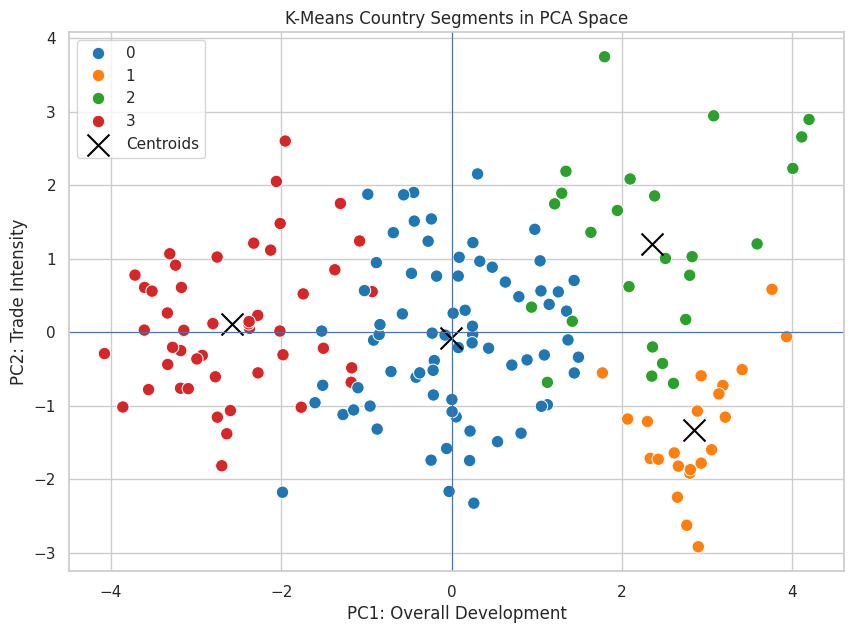

In [41]:
plt.figure(figsize=(10,7))

sns.scatterplot(data=x_pca_df,x='PC1',y='PC2',hue='KMeans_Cluster',palette='tab10',s=80)

centroids=kmeans.cluster_centers_

plt.scatter(centroids[:,0],centroids[:,1],marker='x',s=250,c='black',label='Centroids')

plt.axhline(0,linewidth=0.8)
plt.axvline(0,linewidth=0.8)

plt.title("K-Means Country Segments in PCA Space")
plt.xlabel("PC1: Overall Development")
plt.ylabel("PC2: Trade Intensity")
plt.legend()
plt.show()

In [42]:
cluster_profile_mean=df_results.groupby('KMeans_Cluster')[num_cols].mean().round(2)
cluster_profile_mean

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,23.46,35.81,6.29,45.11,10369.45,7.90,72.44,2.33,5361.81
1,4.72,36.02,10.45,34.65,39190.91,1.44,80.63,1.80,44522.73
2,8.23,83.54,5.95,71.46,42348.00,5.04,77.56,1.89,28150.00
3,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38


In [43]:
cluster_profile_median=df_results.groupby('KMeans_Cluster')[num_cols].median().round(2)
cluster_profile_median

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,19.2,33.20,5.88,47.90,9720.0,5.99,73.10,2.27,4440.0
1,4.2,32.65,9.87,31.95,39300.0,0.93,80.95,1.87,43200.0
2,7.0,70.00,6.03,65.40,30400.0,2.88,77.50,1.86,20700.0
3,90.2,23.80,5.66,40.30,1870.0,8.92,59.50,5.06,897.0


In [44]:
profile_zscores=(df_results.groupby('KMeans_Cluster')[num_cols].mean().apply(lambda col:(col-df[num_cols].mean()[col.name])/df[num_cols].std()[col.name]))
profile_zscores.round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,-0.37,-0.19,-0.19,-0.07,-0.35,0.01,0.21,-0.41,-0.41
1,-0.83,-0.19,1.32,-0.51,1.14,-0.60,1.13,-0.76,1.72
2,-0.74,1.55,-0.32,1.01,1.31,-0.26,0.79,-0.70,0.83
3,1.36,-0.44,-0.16,-0.19,-0.68,0.40,-1.28,1.36,-0.60


In [45]:
overall_mean=df[num_cols].mean()
overall_std=df[num_cols].std()

cluster_profile_z=(df_results.groupby('KMeans_Cluster')[num_cols].mean()-overall_mean)/overall_std
cluster_profile_z.round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,-0.37,-0.19,-0.19,-0.07,-0.35,0.01,0.21,-0.41,-0.41
1,-0.83,-0.19,1.32,-0.51,1.14,-0.60,1.13,-0.76,1.72
2,-0.74,1.55,-0.32,1.01,1.31,-0.26,0.79,-0.70,0.83
3,1.36,-0.44,-0.16,-0.19,-0.68,0.40,-1.28,1.36,-0.60


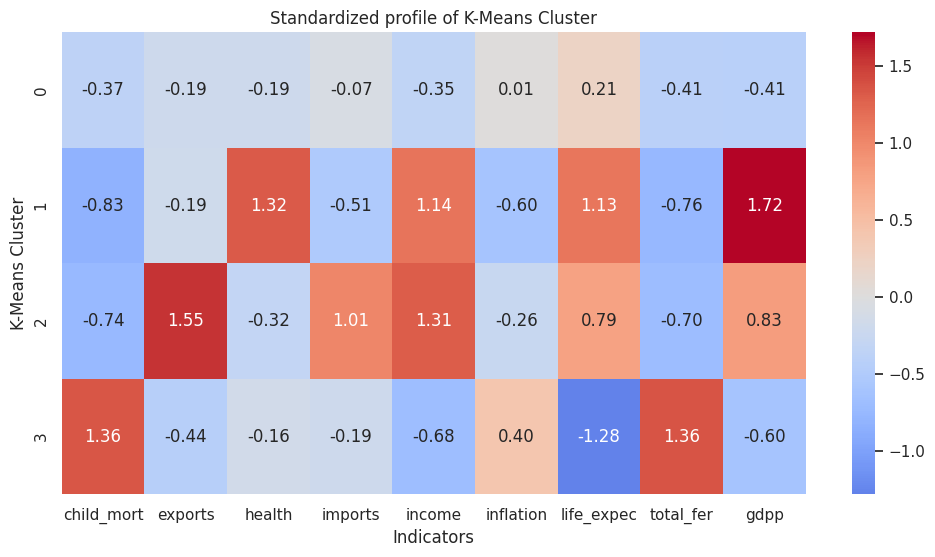

In [46]:
plt.figure(figsize=(12,6))
sns.heatmap(cluster_profile_z,annot=True,cmap='coolwarm',center=0,fmt='0.2f')
plt.title("Standardized profile of K-Means Cluster")
plt.xlabel("Indicators")
plt.ylabel("K-Means Cluster")
plt.show()

In [47]:
#countries in each cluster
for cluster in sorted(df_results['KMeans_Cluster'].unique()):
  print(f"Cluster:{cluster}")
  display(df_results.loc[df_results['KMeans_Cluster']==cluster,['country']].sort_values('country'))

Cluster:0


,country
1,Albania
2,Algeria
4,Antigua and Barbuda
5,Argentina
6,Armenia
...,...
160,Uruguay
161,Uzbekistan
162,Vanuatu
163,Venezuela


Cluster:1


,country
7,Australia
8,Austria
10,Bahamas
29,Canada
44,Denmark
53,Finland
54,France
58,Germany
60,Greece
68,Iceland


Cluster:2


,country
11,Bahrain
15,Belgium
23,Brunei
42,Cyprus
43,Czech Republic
51,Estonia
67,Hungary
73,Ireland
82,Kuwait
89,Libya


Cluster:3


,country
0,Afghanistan
3,Angola
17,Benin
21,Botswana
25,Burkina Faso
26,Burundi
28,Cameroon
31,Central African Republic
32,Chad
36,Comoros


In [48]:
from sklearn.metrics import pairwise_distances_argmin_min
closes_indices,distances=pairwise_distances_argmin_min(kmeans.cluster_centers_,X_cluster)

representative_countries=pd.DataFrame({
    'Cluster':range(final_k),
    'Representative Country':df.loc[closes_indices,'country'].values,
    "Distance From Centroid":distances
})
representative_countries

,Cluster,Representative Country,Distance From Centroid
0,0,Ukraine,0.480693
1,1,Finland,0.376505
2,2,Bahrain,0.897091
3,3,Benin,0.599954


## Q6. What is the business purpose of identifying the country closest to a cluster's centroid (the "representative country") for policy communication?

Ans. The representative country is the actual country located nearest to the mathematical center of the cluster. It provides concrete example of the typical socio-economic profile represented by that segment.
THis helps policy makers communicate complex clustering results in an understandable way. Instead of explaining statistical and mathematical of clusters, they can use familiar country as an illustrative reference point.
However, the representative country cannot be treated as identical to every country in the segment. It is a communication aid and a practical benchmark, not a substitute for country-specific analysis.

Interpretation from the K-Means Clusters:

Cluster 0: Transitional Middle Developmental Economies (Rep. Country=Ukraine)

Profile:
- Comparitively low child mortality
- Slightly above average income and GDP per capita
- Slightly above average life expectancy
- Below avergae fertitlity
- Trade, inflation, health expenditure close to global average
- Median Country: Child mortality=19.2, Income=9720, Life Expectancy=73.1, Fertility=2.27, GDP Per Capita=4440

Interpretation:
- Lower-middle-income countries
- Transition Economies
- Countries with improving health outcomes
- Economies requiring productivity and institutional development rather than emergency aid

Policy recommendation:
- JOb creation and productivity growth
- Industrial deiversification
- Education and Workforce development
- Infrastructure modernization
- Improving institutional and financial resilience
- Preventing regression during economic shocks

Cluster 1: High Income, Health-advanced Economies (Rep. Country=Finland)

Profile:
- Very low child mortality
- highest health expenditure
- High Income
- Highest Life expectancy
- Very low inflation
- Very low fertility
- Highest GDP per capita
- Mean country: Child mortality=4.72, Income=39190, Life Expectancy=80.6, GDP Per Capita=44522

Interpretation:
- Ageing populations
- low fertility
- Healthcare sustainability
- Unlike vulnerable countries they do not require basic developmental needs

POlicy Recommendations:
- Focus on ageing and elderly care
- Healthcare efficiency and digital health
- Labor-force participation
- Skilled migration where appropriate
- Innovation and research
- Climate resilience
- International devlopment partnerships

Cluster 2: HIgh-Income Trade-Intensive Economies (Rep. Country=Bahrain)

Profile:
- Very high Imports
- Very high exports
- HIgh Income
- High GDP per Capita
- Low child mortality
- High Life expectancy
- Relatively moderate health spending
- Mean country: Exports=84.5% of GDP, Imports=71% of GDP, Income=42.438, Life expectancy=77.5, GDP per capita=28150

Interpretation:
- Small open economies
- POrt and logistics hubs
- Resource-exporting economies
- Financial or commerical centers
- Countries integrated deeply into global supply chains
- Lower health expenditure

Policy recommendation:
- Trade diversification
- Supply-chain resilience
- Export value addition
- Reducing excessive dependency on a few products or markets
- Strengthening strategic reserves or and logistics resilience
- Strenghtening domestic product capacity
- Investing in health, skills and long-term development

Cluster 3: High-Need Vulnerable Economies (Rep. Country=Benin)

Profile:
- Highest child mortality
- lowest Income
- lowest life expectancy
- Highest fertility
- lowest GDP per capita
- Higher than average inflation
- Lower exports
- Mean country: Child_mortality=92, Income=3942, Inflation=12, Life expectancy=59, Fertility=5, GDP per capita=1922
- While median country: Child mortality=90, GDP per capita=897,Income=1870, Life expectancy=59
- Large difference between mean and median implies that a few better-of countries are pulling up the mean and a typical country in this cluster is extremely vulnerable

Interpretation:
- Interconnected challenges across health, education, infrastructure, nutrition, governance, and stability

Policy Recommendation:
- Maternal and child care
- Vaccination and nutrition
- Clean water and sanitation
- Primary education
- Reproductive helathcare
- Food Security
- Rural infrastructure
- Employment generation
- Inflation stabilization
- Targeted concessional and financial grants

## Q5. Segment A has high income and high health spend. Segment B has low income and low health spend. What distinct policy goal should be set for Segment A vs. Segment B?

Ans. For high-income, high-health spending economies, the policy goal must be to focus on improving efficiency, sustainability, and quality of existing healthcare systems. Priorites may include healthy ageing, digital health, preventive care, cost control, and advanced medical innocation.
For low-income, low-health spending economies, the primary goal must be to focus on expanding basic healthcare access and improving essential health outcomes. Priorites must include maternal and child healthcare, vaccination, nutrition, sanitation, clean water access, primary care infrastructure, and affordable access to essential medicines.

## Q7. A cluster profile shows high average exports and imports but low gdpp. What is the immediate, tailored policy recommendation for this "Mid-Income Traders" segment?

Ans. An economy with high exports and imports but low gdp per capita may be participating heavily in interantional trade without retaining enough value domestically.
The policy recommendation should be to improve domestic value addition. This includes devloping local processing, manufacturing, Strenghtening domestic suppliers networks, improving logistics efficiency, investing in workforce skills, and supporting business that move the country higher in export value chain.
The goal should not just be to increase trade volume, but ensure that the trade creates domestic income, employment, and productive cpacity.

In [49]:
!pip install scipy

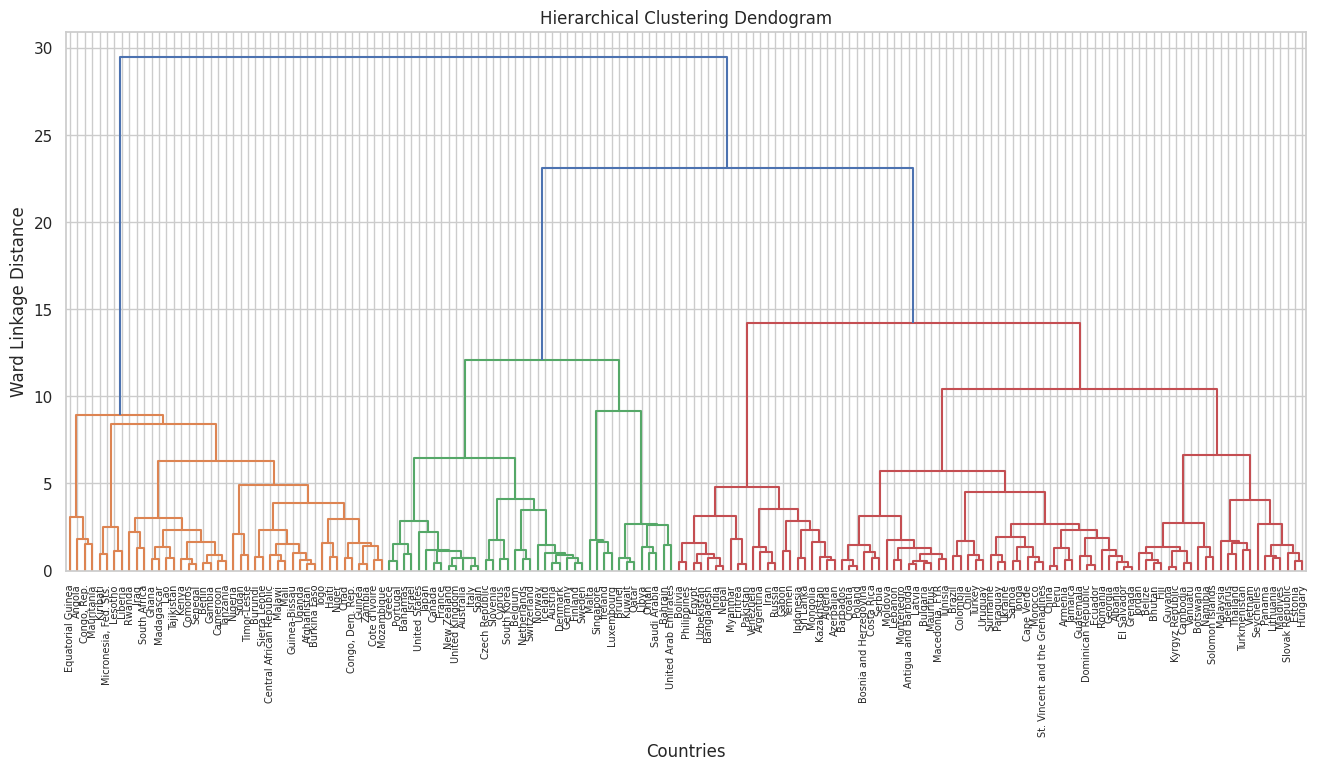

In [50]:
from scipy.cluster.hierarchy import linkage, dendrogram
X_hier=X_cluster.copy()
linkage_matrix=linkage(X_hier, method='ward')

plt.figure(figsize=(16,7))

dendrogram(linkage_matrix, labels=df['country'].values,leaf_rotation=90,leaf_font_size=7)

plt.title("Hierarchical Clustering Dendogram")
plt.xlabel("Countries")
plt.ylabel("Ward Linkage Distance")
plt.show()

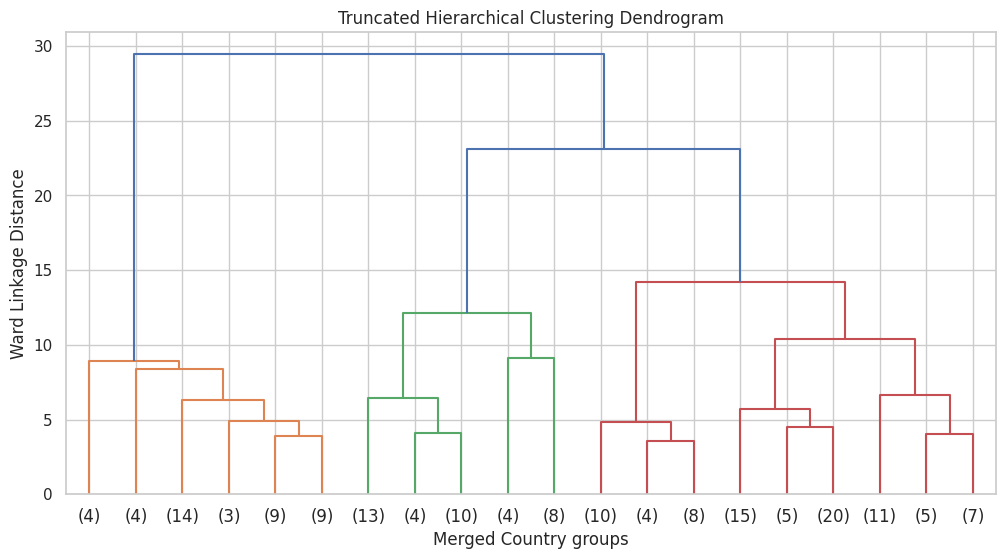

In [51]:
plt.figure(figsize=(12,6))

dendrogram(linkage_matrix,truncate_mode='lastp',p=20,show_leaf_counts=True,leaf_rotation=0)

plt.title("Truncated Hierarchical Clustering Dendrogram")
plt.xlabel("Merged Country groups")
plt.ylabel("Ward Linkage Distance")
plt.show()

### Q4. What unique policy insight does a Hierarchical Clustering Dendrogram offer that a K-Means scatter plot does not, regarding the relationships between clusters?

Ans. THe dendrogram shows the sequence and distance at which countries or country groups merge. This reveals cluster membership as well as closeness of different segments.
Segments that merge at low linkage level have same socio-economic structures and tend to get benefitted from similar policy frameworks whereas ones that merge at high distances are more socio-economically different and may require different interventions.
A K-Means scatter plot shows the final partition and cluster locations, but it does not show the nested relationshipsbetween the clusters or the order in which groups become similar. Here, dendrogram helps policymakers form broader development families and how granular the segmentation should be.

In [52]:
from sklearn.cluster import AgglomerativeClustering

hierarchical_model=AgglomerativeClustering(n_clusters=4,linkage='ward')
hierarchical_labels=hierarchical_model.fit_predict(X_hier)

df_results['Hierarchical_Cluster']=hierarchical_labels
x_pca_df['Hierarchical_Cluster']=hierarchical_labels

In [53]:
hierarchical_cluster_sizes=df_results['Hierarchical_Cluster'].value_counts().sort_index().rename_axis('Cluster').reset_index(name='Number of Countries')

hierarchical_cluster_sizes

,Cluster,Number of Countries
0,0,39
1,1,43
2,2,63
3,3,22


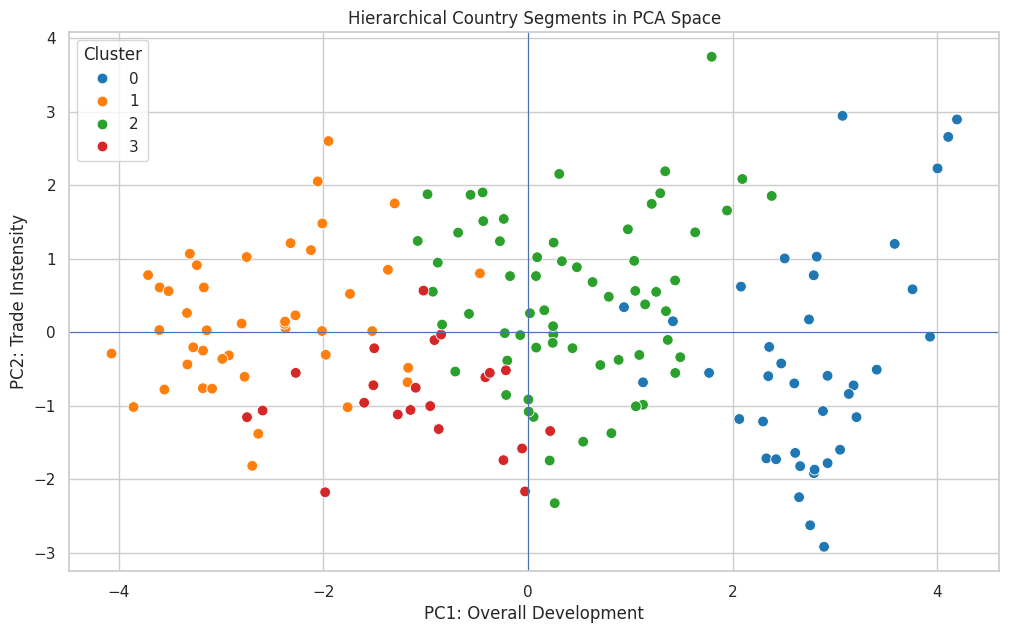

In [54]:
plt.figure(figsize=(12,7))

sns.scatterplot(data=x_pca_df,x='PC1',y='PC2',hue='Hierarchical_Cluster',palette='tab10',s=60)

plt.axhline(0,linewidth=0.80)
plt.axvline(0,linewidth=0.80)

plt.title("Hierarchical Country Segments in PCA Space")
plt.xlabel("PC1: Overall Development")
plt.ylabel("PC2: Trade Instensity")
plt.legend(title='Cluster')
plt.show()

In [55]:
hierarchical_profile_mean=df_results.groupby('Hierarchical_Cluster')[num_cols].mean().round(2)
hierarchical_profile_mean

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Hierarchical_Cluster,,,,,,,,,
0,5.92,57.80,8.39,49.64,45184.62,3.65,79.75,1.84,40817.95
1,95.02,28.17,6.79,44.67,3334.95,11.77,59.16,5.09,1647.16
2,19.43,44.26,6.71,54.04,11823.97,4.56,73.02,2.22,6507.24
3,38.65,27.81,4.38,25.88,9665.91,16.55,69.47,2.82,4196.82


In [56]:
hierarchical_profile_median=df_results.groupby('Hierarchical_Cluster')[num_cols].median().round(2)
hierarchical_profile_median

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Hierarchical_Cluster,,,,,,,,,
0,4.3,50.20,9.40,40.70,40700.0,1.57,80.30,1.86,38900.0
1,90.3,23.50,5.89,42.90,1850.0,7.64,59.50,5.20,758.0
2,17.4,40.10,6.68,53.10,10500.0,3.86,74.00,2.13,5190.0
3,34.8,26.45,4.47,24.95,8070.0,15.20,69.05,2.60,2625.0


In [59]:
hierarchical_profile_z = (
    df_results
    .groupby('Hierarchical_Cluster')[num_cols]
    .mean()
    - df[num_cols].mean()
) / df[num_cols].std()

hierarchical_profile_z.round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Hierarchical_Cluster,,,,,,,,,
0,-0.80,0.61,0.57,0.11,1.45,-0.39,1.03,-0.73,1.52
1,1.41,-0.47,-0.01,-0.09,-0.72,0.38,-1.28,1.41,-0.62
2,-0.47,0.11,-0.04,0.30,-0.28,-0.31,0.28,-0.48,-0.35
3,0.01,-0.49,-0.89,-0.87,-0.39,0.83,-0.12,-0.09,-0.48


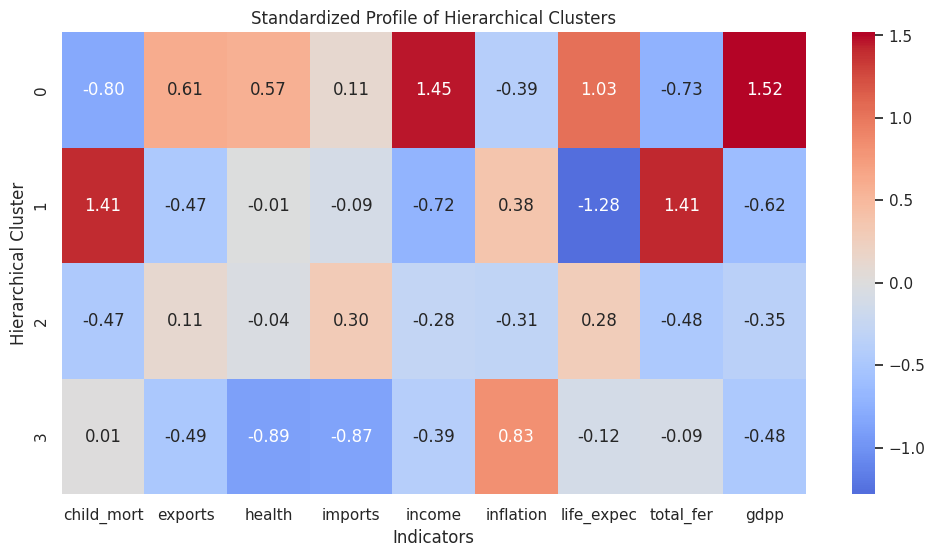

In [60]:
plt.figure(figsize=(12,6))

sns.heatmap(hierarchical_profile_z,annot=True,cmap='coolwarm',fmt='0.2f',center=0)

plt.title('Standardized Profile of Hierarchical Clusters')
plt.xlabel('Indicators')
plt.ylabel('Hierarchical Cluster')
plt.show()

## Hierarchical Clustering and Dendrogram Interpretability
Hierarchical clustering was applied to four PCA componenets using ward linkages.
The dendrogram shows how the countries and country groups merge. Several large increases in linkage distances are visible before the final merge, indicating the presence of broader socio-economic country families.
A four-cluster solution was selected to preserve the major branches of the dendrogram and allow a direct comparison with the four cluster K-Means model. However, the dendrogram does not provide one perfectly unambiguous cut, so the final validation must also consider internal validation metrics, and cluster interpretability.

In [61]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

hierarchical_metrics={
    'Silhouette Score':silhouette_score(X_hier,hierarchical_labels),
    'Davies-Bouldin Index':davies_bouldin_score(X_hier,hierarchical_labels),
    'Calinski Harabaaz Index':calinski_harabasz_score(X_hier,hierarchical_labels)
}

pd.DataFrame(hierarchical_metrics.items(),columns=['Metric','HIerarchical Clustering'])

,Metric,HIerarchical Clustering
0,Silhouette Score,0.274953
1,Davies-Bouldin Index,1.114075
2,Calinski Harabaaz Index,82.316488


SInce cluster numbers are arbitrary, a cross-tabulation will show the overlap

In [62]:
cluster_comparison=pd.crosstab(df_results['KMeans_Cluster'],df_results['Hierarchical_Cluster'],rownames=['K-Means'],colnames=['Hierarchical'])
cluster_comparison

Hierarchical,0,1,2,3
K-Means,,,,
0,0,2,53,18
1,22,0,0,0
2,17,0,8,0
3,0,41,2,4


## Cross-Tabulation Interpretation
|K-Means|Hierarchical Destination|
|--------|-------------|
|K-Means 0|Mostly in hierarchical cluster 2, with few in 3|
|K-Means 1|Entirely in Hierarchical cluster 0|
|K-Means 2|Mostly in Hierarchical cluster 0 with few in 2|
|K-Means 3|Mostly in 1 with very few spread in 2,3|

Strong areas of agreement:
- K-Means Cluster 1: All 22 countries are placed in Hierarchical cluster 0, meaning both models strongly agree on highly developed, high income group
- K-Means CLuster 3: 41 out of 47 countries fall in Hierarchical cluster 1, also implying that both models strongly agree on vulnerable, high-development-need segment

Main areas of disagreement:
- K-Means Cluster 2, the trade affluent segment is divided by Hierarchical clustering: 17 countries fall under affluent cluster 0 and 8 under emerging cluster 2. This suggests that trade intesive cluster contains 2 subgroups: Wealthy-developed trade economies and Moderately developed trade-oriented countries

In [63]:
from sklearn.metrics import adjusted_rand_score
ari_kmeans_hierarchical=adjusted_rand_score(kmeans_labels,hierarchical_labels)
# ARI compares memberships without being affected by cluster-number labels
print("Adjusted Rand Index between K-Means and Hierarchical:",round(ari_kmeans_hierarchical,2))

Adjusted Rand Index between K-Means and Hierarchical: 0.55


## Agreement between K-Means Cluster and Hierarchical Clustering
The adjusted Rand Index between K-Means and Hierarchical solutions is approximately 0.55.
This indicates moderate to strong agreement between the two clustering methods. Both models consistently identify a highly developed segment and a vulnerable high-need requiring segments.
The main difference occurs among middle-development and trade-oriented countries. Hierarchical clustering splits some of these coutnries into an additional group characterised by low trade integration, low health expenditure, and high inflation.
Therfore, both the models support the same broad classification, but differ in how they divide internediate country profiles.

K-Means achieves a silhouette score of 0.328 whereas Hierarchcical cluster achieved a score of 0.275, indicating K-means has better separation and cohesion compared to the other.
THerefore, K-Means appears to be a more suitable segmentation model and Hierarchical cluster offers additional insights into nested relationships and intermediate groups.

## DBSCAN clustering

DBSCAN is applied to identify dense groups of countries and isolate countries with unusual socio-economic profiles as noise.
Unlike K-Means and Hierarchical Clustering, DBSCAN does not require the number of clusters to be specified in advance. Instead, it uses 2 parameters: eps=maximum neighbourhood distance and min_samples=minimum number of neighbouring observations required to form a dense region
A k-distance plot was used to find a potential elbow for eps. Multiple combinations of eps and min_samples are used to evaluate.
The final parameter selection will be done after considering internal validation metrics, number of clusters, percentage of countries classified as noise, cluster size, and business interpretability.

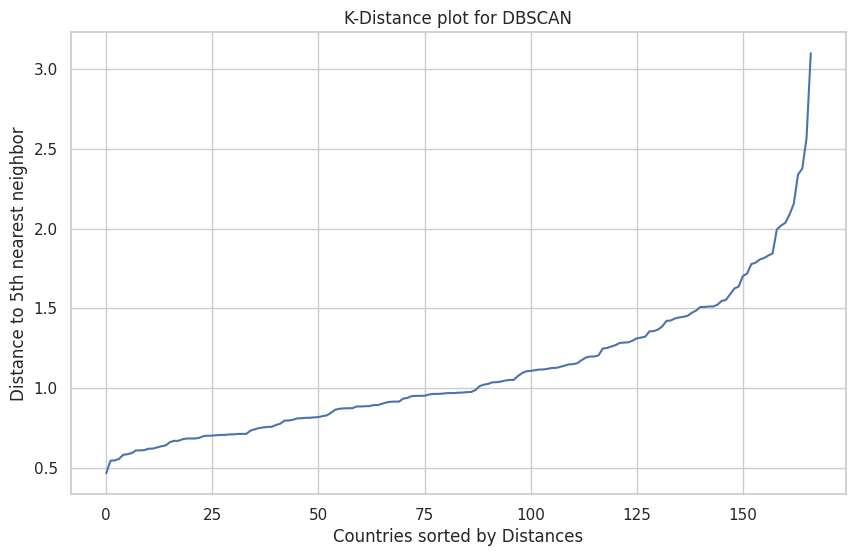

In [66]:
from sklearn.neighbors import NearestNeighbors
min_samples=5
neighbors=NearestNeighbors(n_neighbors=min_samples)
neighbors_fit=neighbors.fit(X_cluster)
distances,indices=neighbors_fit.kneighbors(X_cluster)
k_distances=np.sort(distances[:,min_samples-1])

plt.figure(figsize=(10,6))
plt.plot(k_distances)
plt.xlabel("Countries sorted by Distances")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.title("K-Distance plot for DBSCAN")
plt.grid(True)
plt.show()

In [67]:
from sklearn.cluster import DBSCAN

eps_values=np.arange(0.8,2.1,0.1)
min_samples_values=[4,5,6,7,8]

dbscan_results=[]

for min_samples_value in min_samples_values:
  for eps_value in eps_values:
    model=DBSCAN(eps=eps_value,min_samples=min_samples_value)
    labels=model.fit_predict(X_cluster)
    non_noise_mask=labels!=-1
    non_noise_labels=labels[non_noise_mask]
    non_noise_data=X_cluster.loc[non_noise_mask]
    n_clusters=len(set(labels))-(1 if -1 in labels else 0)
    n_noise=np.sum(labels==-1)

    if n_clusters>=2 and len(set(non_noise_labels))>=2:
      sil=silhouette_score(non_noise_data,non_noise_labels)
      dbi=davies_bouldin_score(non_noise_data,non_noise_labels)
      chi=calinski_harabasz_score(non_noise_data,non_noise_labels)
    else:
      sil=np.nan
      dbi=np.nan
      chi=np.nan
    dbscan_results.append({
        'eps':round(eps_value,2),
        'min_samples':min_samples_value,
        'clusters':n_clusters,
        'noise_points':n_noise,
        'noise_percentage':round(n_noise/len(X_cluster)*100,2),
        'silhouette':sil,
        'davies_bouldin':dbi,
        'calisnki_harabasz':chi
    })
dbscan_results_df=pd.DataFrame(dbscan_results)

dbscan_results_df.sort_values(by='silhouette',ascending=False).head(20)

,eps,min_samples,clusters,noise_points,noise_percentage,silhouette,davies_bouldin,calisnki_harabasz
26,0.8,6,3,106,63.47,0.639361,0.479353,174.318631
53,0.9,8,3,98,58.68,0.594652,0.528665,161.017622
40,0.9,7,3,88,52.69,0.571306,0.566345,157.468994
39,0.8,7,4,120,71.86,0.524654,0.686240,151.241721
52,0.8,8,3,138,82.63,0.500967,0.761627,121.737546
13,0.8,5,4,93,55.69,0.470746,0.625407,117.162880
54,1.0,8,3,64,38.32,0.461069,0.647694,108.847151
41,1.0,7,2,61,36.53,0.417246,0.705429,61.955963
28,1.0,6,2,59,35.33,0.414023,0.707629,61.446464
42,1.1,7,2,52,31.14,0.406222,0.718055,63.440600


In [68]:
practical_dbscan_results = dbscan_results_df[
    (dbscan_results_df['clusters'] >= 2) &
    (dbscan_results_df['clusters'] <= 6) &
    (dbscan_results_df['noise_percentage'] <= 30)
].sort_values(
    by=['silhouette', 'noise_percentage'],
    ascending=[False, True]
)

practical_dbscan_results.head(20)

,eps,min_samples,clusters,noise_points,noise_percentage,silhouette,davies_bouldin,calisnki_harabasz
56,1.2,8,2,46,27.54,0.375279,0.730929,53.291356
33,1.5,6,2,12,7.19,0.223878,0.864663,9.733811
47,1.6,7,2,12,7.19,0.223878,0.864663,9.733811
62,1.8,8,2,5,2.99,0.218829,0.917927,11.142398
5,1.3,4,2,19,11.38,0.212368,0.961329,10.494406
6,1.4,4,2,13,7.78,0.202067,0.973247,10.194711
19,1.4,5,2,15,8.98,0.194414,0.984142,8.327669
3,1.1,4,2,36,21.56,0.084267,0.940071,4.214146


In [69]:
best_eps=1.2
best_min_samples=8
dbscan_model=DBSCAN(eps=best_eps,min_samples=best_min_samples)
dbscan_labels=dbscan_model.fit_predict(X_cluster)
df_results['DBSCAN_Cluster']=dbscan_labels
x_pca_df['DBSCAN_Cluster']=dbscan_labels

In [70]:
dbscan_cluster_sizes=df_results['DBSCAN_Cluster'].value_counts().sort_index().rename_axis('Cluster').reset_index(name='Number of Countries')
dbscan_cluster_sizes

,Cluster,Number of Countries
0,-1,46
1,0,104
2,1,17


In [72]:
n_dbscan_clusters=len(set(dbscan_labels))-(1 if -1 in dbscan_labels else 0)

n_noise=np.sum(dbscan_labels==-1)

print("Number of DBSCAN CLusters:",n_dbscan_clusters)
print("Number of noise countries:",n_noise)
print("Noise Percentage:",round(n_noise / len(dbscan_labels) * 100, 2),"%")

Number of DBSCAN CLusters: 2
Number of noise countries: 46
Noise Percentage: 27.54 %


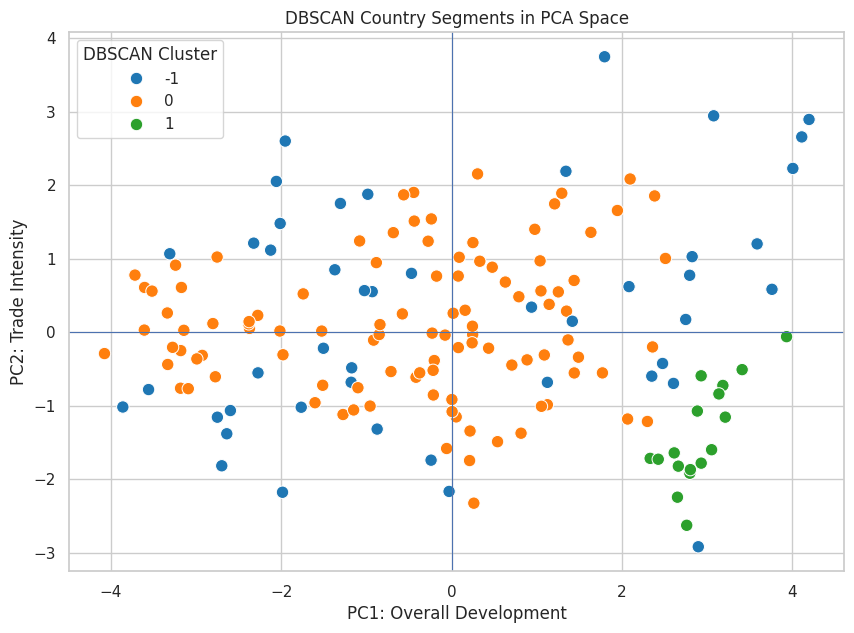

In [74]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=x_pca_df,x='PC1',y='PC2',hue='DBSCAN_Cluster',palette='tab10',s=80)
plt.axhline(0,linewidth=0.8)
plt.axvline(0,linewidth=0.8)

plt.title("DBSCAN Country Segments in PCA Space")
plt.xlabel("PC1: Overall Development")
plt.ylabel("PC2: Trade Intensity")
plt.legend(title='DBSCAN Cluster')
plt.show()

In [80]:
noise_countries = (
    df_results.loc[
        df_results['DBSCAN_Cluster'] == -1,
        ['country'] + list(num_cols)
    ]
    .sort_values('country')
)

noise_countries

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
3,Angola,119.0,62.300,2.85,42.9000,5900,22.400,60.1,6.16,3530
5,Argentina,14.5,18.900,8.10,16.0000,18700,20.900,75.8,2.37,10300
11,Bahrain,8.6,69.500,4.97,50.9000,41100,7.440,76.0,2.16,20700
15,Belgium,4.5,76.400,10.70,74.7000,41100,1.880,80.0,1.86,44400
21,Botswana,52.5,43.600,8.30,51.3000,13300,8.920,57.1,2.88,6350
23,Brunei,10.5,67.400,2.84,28.0000,80600,16.700,77.1,1.84,35300
38,"Congo, Rep.",63.9,85.100,2.46,54.7000,5190,20.700,60.4,4.95,2740
42,Cyprus,3.6,50.200,5.97,57.5000,33900,2.010,79.9,1.42,30800
49,Equatorial Guinea,111.0,85.800,4.48,58.9000,33700,24.900,60.9,5.21,17100
50,Eritrea,55.2,4.790,2.66,23.3000,1420,11.600,61.7,4.61,482


In [81]:
noise_countries_pca = (
    x_pca_df.loc[
        x_pca_df['DBSCAN_Cluster'] == -1,
        ['country', 'PC1', 'PC2', 'PC3', 'PC4']
    ]
    .sort_values('country')
)

noise_countries_pca

,country,PC1,PC2,PC3,PC4
3,Angola,-3.306409,1.066649,-2.151219,1.698677
5,Argentina,-0.028633,-2.167692,-1.043483,-0.034250
11,Bahrain,2.082711,0.619474,-1.372070,0.603330
15,Belgium,3.586013,1.200735,0.628677,1.430759
21,Botswana,-0.930563,0.550561,0.473512,0.493385
23,Brunei,2.349842,-0.598960,-3.122378,1.374735
38,"Congo, Rep.",-2.055580,2.050865,-2.465050,0.842669
42,Cyprus,2.748024,0.172301,-0.320206,0.189674
49,Equatorial Guinea,-1.303845,1.751070,-2.481214,3.164564
50,Eritrea,-2.747750,-1.157631,-0.779733,-0.616065


In [83]:
dbscan_profile_mean=df_results[df_results['DBSCAN_Cluster']!=-1].groupby('DBSCAN_Cluster')[num_cols].mean().round(2)
dbscan_profile_mean

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
DBSCAN_Cluster,,,,,,,,,
0,41.63,36.25,6.34,45.92,9681.76,6.23,69.25,3.01,5535.74
1,4.11,35.77,10.21,33.46,40447.06,1.62,81.15,1.74,47041.18


In [85]:
dbscan_profile_z=(df_results[df_results['DBSCAN_Cluster']!=-1].groupby('DBSCAN_Cluster')[num_cols].mean()-df[num_cols].mean())/df[num_cols].std()
dbscan_profile_z.round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
DBSCAN_Cluster,,,,,,,,,
0,0.08,-0.18,-0.17,-0.04,-0.39,-0.15,-0.15,0.04,-0.41
1,-0.85,-0.19,1.23,-0.55,1.21,-0.58,1.19,-0.80,1.86


In [88]:
non_noise_mask=dbscan_labels!=-1
X_dbscan_non_noise=X_cluster.loc[non_noise_mask]
labels_dbscan_non_noise=dbscan_labels[non_noise_mask]

if len(set(labels_dbscan_non_noise))>=2:
  dbscan_metrics=pd.DataFrame({
      'Metric':['Silhouette Score','Davies-Bouldin Index','Calisnki-Harabasz Index'],
      'DBSCAN':[silhouette_score(X_dbscan_non_noise,labels_dbscan_non_noise),davies_bouldin_score(X_dbscan_non_noise,labels_dbscan_non_noise),calinski_harabasz_score(X_dbscan_non_noise,labels_dbscan_non_noise)]
  })
else:
  print("DBSCAN did not produce even 2 clusters")
display(dbscan_metrics)

,Metric,DBSCAN
0,Silhouette Score,0.375279
1,Davies-Bouldin Index,0.730929
2,Calisnki-Harabasz Index,53.291356


## DBSCAN Results and Interpretation

The k-distance plot showed a noticeable increase in slope around a distance between 1.2 to 1.5, after considering different parameter combinations eps=1.2 and min_samples=8 were selected.

The final DBSCAN model identified 2 clusters containing 104 and 17 countries respectively. It also classifies 46 countries (~27.64%) as noise.

The non-noise observations produced a Silhouette score of 0.375, a Davies-Bouldin score of 0.731, and Calinski-Harabasz score of 53.29. Although Silhouette score is higher than K-Means and Hierarchical clustering, this excludes some countries as noise. Therefore, the results are not directly comparable with models that assign every country  to a cluster.

The larger DBSCAN cluster contains a broad range of country profiles, while the smaller cluster appears to represent a copact group of highly developed economies. The noise cluster contians both kinds of countries that include ones experiencing severe socio-economic stress (E.g: Nigeria, Venezuela) and structurally unusually high-income or trade-instensive economies (E.g: Singapore, Luxemborg).

Therefore, observations show that DBSCAN is useful in identifying unusual country profiles. However, it only creates 2 clusters and leaves nearly 27% of countries unassigned, so it is less suitable than K-Means as the primary global development segmentation model

## Model Comparison:
|Model|Clusters|Noise|Silhouette|Strength|Weakness|
|-----|--------|-----|----------|--------|--------|
|K-Means|4|0|0.328|Clear, actionable policy segments|Assumes compact cluster structure|
|Hierarchical|4|0|0.275|Shows nested relationships|More overlap and weaker relationships|
|DBSCAN|2|46|0.375|Identifies unusual countries|Too many noise points and broad clusters|

## Results and Policy Recommendation

Key findings from the clustering analysis

The clustering analysis identified 4 cluster groups with distinct socio-economic characteristics. K-Means was selected as the primary development segmentation method because it clearly assigned countries into clearly interpretable groups and produced cluster separation than Hierarchical clustering broadly confirmed the main development patterns while DBCAN is more useful for identifying country profiles and potential outliers.

Overall Business Interpretation

The analysis confirms that a single devlopment strategy would not be appropriate for all countries. Each segment requires a different policy objective:
- Advanced economies require optimization and long-term sustainability
- Trade-driven countries require diversification and resilience
- Transitional economies require productivity, infrastructure, and institutional development
- Critical-need economies require urgent investment in basic health, education, nutrition, and poverty reduction

Potential Next Steps:
- Comparing the current results with clustering performed on the uncapped dataset to assess the impact of outlier treatment
- Testing cluster stability using different random seeds, PCA component selections, and clustering paramters
- Adding indicators such as Education, unemployment, poverty, public debt, governance, political stability, and infrstructure access
- Conducting regional analysis to understand geographic patterns within each segment
- Reviewing DBSCAN countries individually to identify special policy cases
- Developing an interactive dashboard that allows policy makers to view country membership,; cluster profile, risk indicators, and recommended indicators

Overall, the segmentation provides a practical foundation for the targeted global devlopment planning, but cluster-based recommendations should be combined with country-specific knowledge before final policy decisions are made.